# Conversation Logs Analysis: RAG vs. Control

This notebook analyzes the data from `conversation_logs/conversation_logs_both.csv`, comparing the RAG (`RAG_USER`) and control (`INTENT_USER`) cohorts.

**Initial Filtering:**
- Users registered after January 5, 2026.
- Messages with fewer than 3 words are excluded from message-based analyses.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('conversation_logs/conversation_logs_both.csv')

# Convert date columns to datetime objects
df['user_registration_date'] = pd.to_datetime(df['user_registration_date'])
df['query_timestamp'] = pd.to_datetime(df['query_timestamp'])

# Filter for registration date later than January 23, 2026
df_filtered = df[df['user_registration_date'] > pd.Timestamp('2026-01-22')].copy()
df_filtered = df_filtered[df_filtered['user_registration_date'] < pd.Timestamp('2026-02-11')].copy()

# Separate into RAG and Control groups
rag = df_filtered[df_filtered['user_cohort'] == 'RAG_USER'].copy()
control = df_filtered[df_filtered['user_cohort'] == 'INTENT_USER'].copy()

print(f'Original file: {df.shape[0]} rows')
print(f'After date filter: {df_filtered.shape[0]} rows')
print('---')
print(f'RAG group: {rag.shape[0]} rows, {rag["account_id"].nunique()} unique users')
print(f'Control group: {control.shape[0]} rows, {control["account_id"].nunique()} unique users')

Original file: 42335 rows
After date filter: 2134 rows
---
RAG group: 1129 rows, 260 unique users
Control group: 1005 rows, 289 unique users


/var/folders/ss/5f4d9xy53vv1sym9cl6ymb280000gq/T/ipykernel_81986/571071096.py:6: DtypeWarning: Columns (4,19,20,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('conversation_logs/conversation_logs_both.csv')


## 1. General Analysis: Age & Location Distributions

In [43]:
# Get per-user demographics (one row per user)
rag_users = rag.drop_duplicates(subset='account_id')[['account_id', 'user_age', 'location_state']]
control_users = control.drop_duplicates(subset='account_id')[['account_id', 'user_age', 'location_state']]

print(f'RAG: {len(rag_users)} unique users')
print(f'Control: {len(control_users)} unique users')

RAG: 268 unique users
Control: 606 unique users


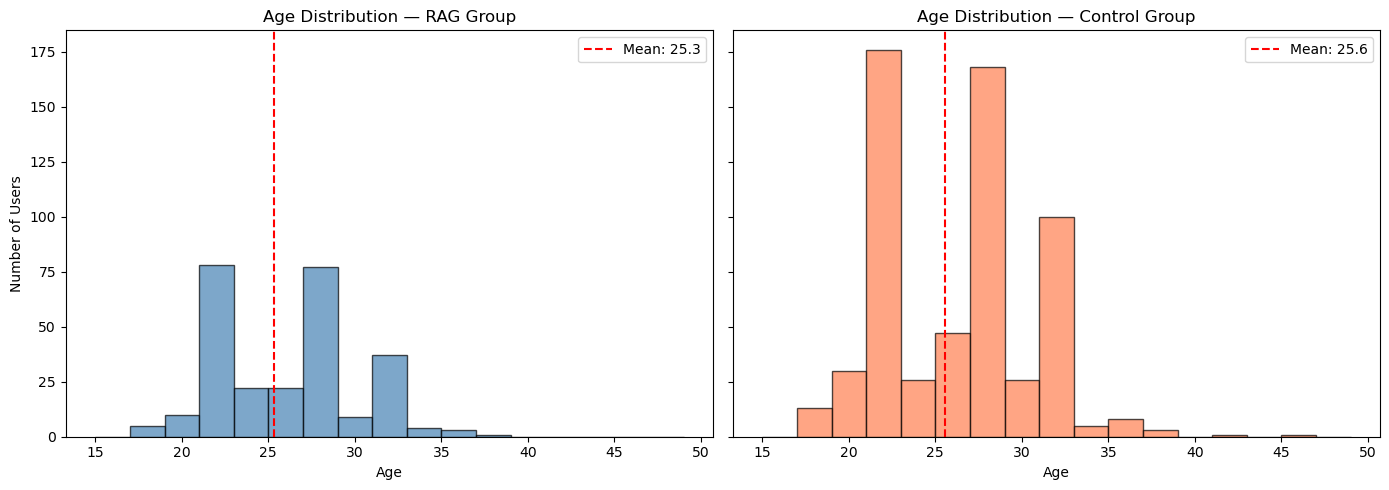


--- RAG Age Summary ---
count    268.000000
mean      25.339552
std        4.060452
min       18.000000
25%       21.000000
50%       26.000000
75%       27.000000
max       38.000000
Name: user_age, dtype: float64

--- Control Age Summary ---
count    605.000000
mean      25.580165
std        4.598690
min       18.000000
25%       21.000000
50%       27.000000
75%       28.000000
max       60.000000
Name: user_age, dtype: float64


In [44]:
# --- Age distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

rag_ages = rag_users['user_age'].dropna()
control_ages = control_users['user_age'].dropna()

bins = np.arange(15, 50, 2)

axes[0].hist(rag_ages, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Age Distribution — RAG Group')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(rag_ages.mean(), color='red', linestyle='--', label=f'Mean: {rag_ages.mean():.1f}')
axes[0].legend()

axes[1].hist(control_ages, bins=bins, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Age Distribution — Control Group')
axes[1].set_xlabel('Age')
axes[1].axvline(control_ages.mean(), color='red', linestyle='--', label=f'Mean: {control_ages.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n--- RAG Age Summary ---')
print(rag_ages.describe())
print('\n--- Control Age Summary ---')
print(control_ages.describe())

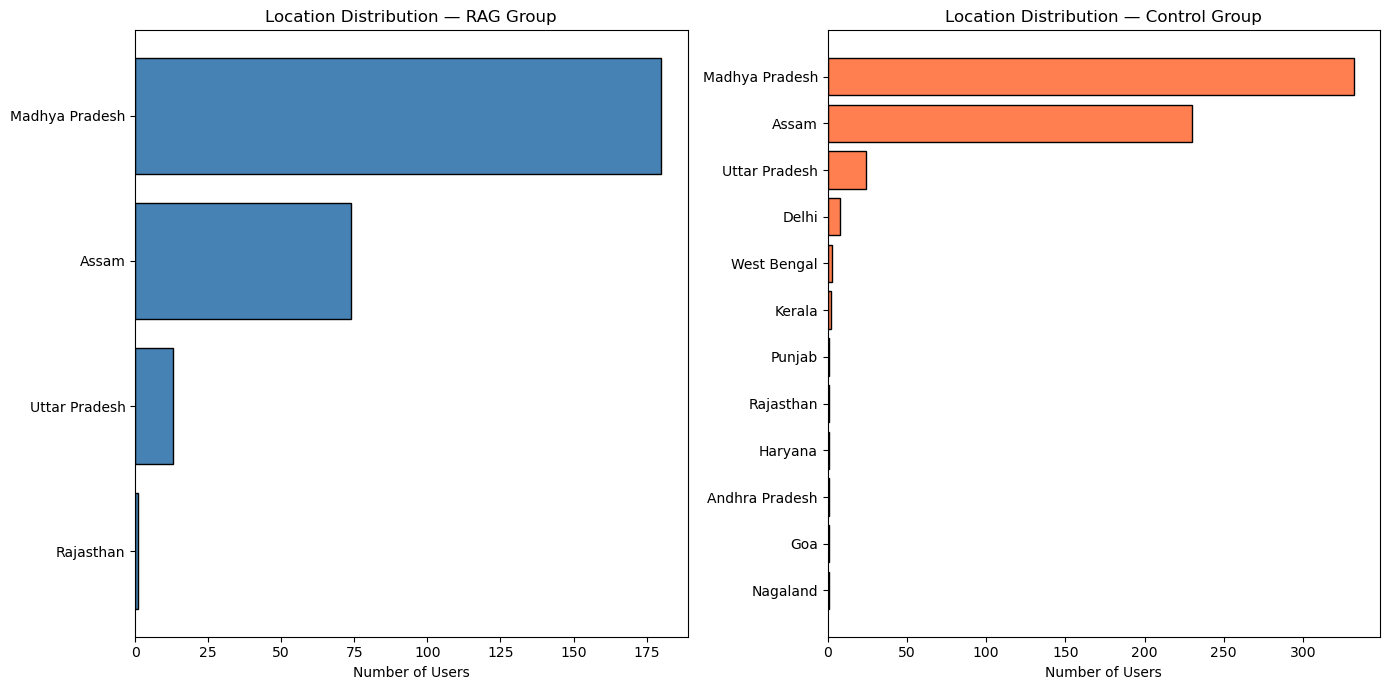


--- RAG Location Counts ---
location_state
Madhya Pradesh    180
Assam              74
Uttar Pradesh      13
Rajasthan           1
Name: count, dtype: int64
Missing: 0

--- Control Location Counts ---
location_state
Madhya Pradesh    332
Assam             230
Uttar Pradesh      24
Delhi               8
West Bengal         3
Kerala              2
Punjab              1
Rajasthan           1
Haryana             1
Andhra Pradesh      1
Goa                 1
Nagaland            1
Name: count, dtype: int64
Missing: 1


In [45]:
# --- Location distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

rag_loc = rag_users['location_state'].value_counts()
control_loc = control_users['location_state'].value_counts()

axes[0].barh(rag_loc.index[:15], rag_loc.values[:15], color='steelblue', edgecolor='black')
axes[0].set_title('Location Distribution — RAG Group')
axes[0].set_xlabel('Number of Users')
axes[0].invert_yaxis()

axes[1].barh(control_loc.index[:15], control_loc.values[:15], color='coral', edgecolor='black')
axes[1].set_title('Location Distribution — Control Group')
axes[1].set_xlabel('Number of Users')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('\n--- RAG Location Counts ---')
print(rag_loc)
print(f"Missing: {rag_users['location_state'].isna().sum()}")
print('\n--- Control Location Counts ---')
print(control_loc)
print(f"Missing: {control_users['location_state'].isna().sum()}")

## 2. Average Number of Messages Per User

In [46]:
# --- Filter messages with < 3 words ---
rag_msg_filtered = rag.copy()
rag_msg_filtered['word_count'] = rag_msg_filtered['user_message'].astype(str).str.split().str.len()
rag_msg_filtered = rag_msg_filtered[rag_msg_filtered['word_count'] >= 3]

control_msg_filtered = control.copy()
control_msg_filtered['word_count'] = control_msg_filtered['user_message'].astype(str).str.split().str.len()
control_msg_filtered = control_msg_filtered[control_msg_filtered['word_count'] >= 3]

# --- RAG group ---
rag_msgs_per_user = rag_msg_filtered.groupby('account_id').size()
print(f'RAG (after filtering): {len(rag_msg_filtered)} messages from {rag_msgs_per_user.shape[0]} users')
print(f'Average messages per user: {rag_msgs_per_user.mean():.2f}')
print('\n')
print(rag_msgs_per_user.describe())

RAG (after filtering): 613 messages from 167 users
Average messages per user: 3.67


count    167.000000
mean       3.670659
std        3.596255
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       21.000000
dtype: float64


In [47]:
# --- Control group ---
control_msgs_per_user = control_msg_filtered.groupby('account_id').size()
print(f'Control (after filtering): {len(control_msg_filtered)} messages from {control_msgs_per_user.shape[0]} users')
print(f'Average messages per user: {control_msgs_per_user.mean():.2f}')
print('\n')
print(control_msgs_per_user.describe())

Control (after filtering): 891 messages from 303 users
Average messages per user: 2.94


count    303.000000
mean       2.940594
std        2.666279
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       22.000000
dtype: float64


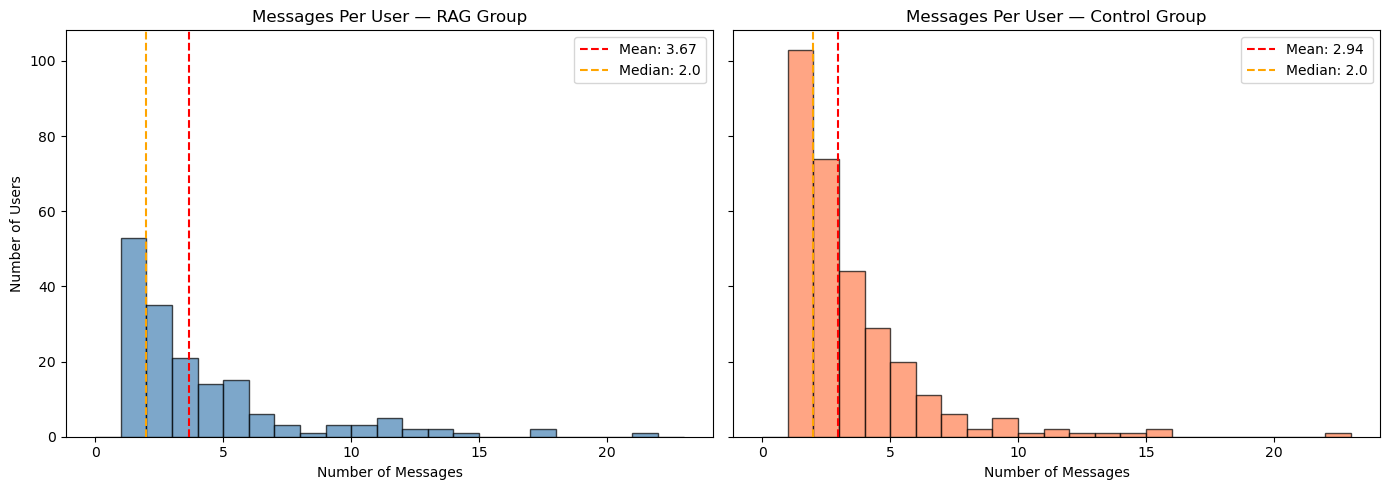

In [48]:
# --- Histogram: Messages Per User (RAG vs. Control) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

max_bin = max(rag_msgs_per_user.max(), control_msgs_per_user.max())
bins = np.arange(0, min(max_bin + 2, 50), 1) # Limit bins for better visualization

axes[0].hist(rag_msgs_per_user, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Messages Per User — RAG Group')
axes[0].set_xlabel('Number of Messages')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(rag_msgs_per_user.mean(), color='red', linestyle='--', label=f'Mean: {rag_msgs_per_user.mean():.2f}')
axes[0].axvline(rag_msgs_per_user.median(), color='orange', linestyle='--', label=f'Median: {rag_msgs_per_user.median():.1f}')
axes[0].legend()

axes[1].hist(control_msgs_per_user, bins=bins, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Messages Per User — Control Group')
axes[1].set_xlabel('Number of Messages')
axes[1].axvline(control_msgs_per_user.mean(), color='red', linestyle='--', label=f'Mean: {control_msgs_per_user.mean():.2f}')
axes[1].axvline(control_msgs_per_user.median(), color='orange', linestyle='--', label=f'Median: {control_msgs_per_user.median():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Average Number of Words Per Message

--- RAG: Words per Message ---
count    613.000000
mean       8.004894
std        4.554497
min        3.000000
25%        5.000000
50%        7.000000
75%       10.000000
max       38.000000
Name: word_count, dtype: float64

--- Control: Words per Message ---
count    891.000000
mean       7.542088
std        4.618864
min        3.000000
25%        5.000000
50%        6.000000
75%        9.000000
max       48.000000
Name: word_count, dtype: float64


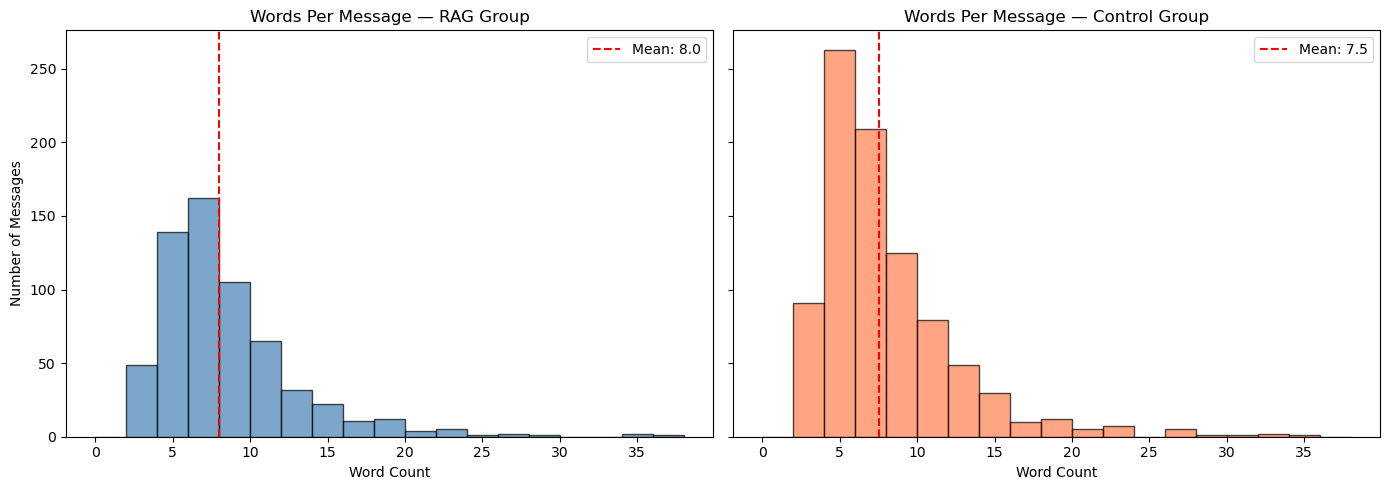

In [49]:
# --- Word count analysis ---
print('--- RAG: Words per Message ---')
print(rag_msg_filtered['word_count'].describe())
print('\n--- Control: Words per Message ---')
print(control_msg_filtered['word_count'].describe())

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
bins = np.arange(0, 40, 2)

axes[0].hist(rag_msg_filtered['word_count'], bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Words Per Message — RAG Group')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Messages')
axes[0].axvline(rag_msg_filtered['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {rag_msg_filtered["word_count"].mean():.1f}')
axes[0].legend()

axes[1].hist(control_msg_filtered['word_count'], bins=bins, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Words Per Message — Control Group')
axes[1].set_xlabel('Word Count')
axes[1].axvline(control_msg_filtered['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {control_msg_filtered["word_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Time Between First and Last Message (Users Registered Before 2/15/2026)

In [50]:
# --- RAG: first/last message per user (registered before 2/15/2026) ---
enroll_end = pd.Timestamp('2026-02-15')
rag_early_reg = rag_msg_filtered[rag_msg_filtered['user_registration_date'] <= enroll_end]

rag_user_times = rag_early_reg.groupby('account_id')['query_timestamp'].agg(['min', 'max'])
rag_user_times.columns = ['first_msg', 'last_msg']
rag_user_times['duration_days'] = (rag_user_times['last_msg'] - rag_user_times['first_msg']).dt.total_seconds() / 86400

print('--- RAG: Time Between First and Last Message (Early Registration) ---')
print(f'Analyzed {len(rag_user_times)} users who registered before {enroll_end.date()}')
print(rag_user_times['duration_days'].describe())

--- RAG: Time Between First and Last Message (Early Registration) ---
Analyzed 167 users who registered before 2026-02-15
count    167.000000
mean       3.556653
std        6.217589
min        0.000000
25%        0.000000
50%        0.003322
75%        5.643964
max       26.276655
Name: duration_days, dtype: float64


In [51]:
# --- Control: first/last message per user (registered before 2/15/2026) ---
enroll_end = pd.Timestamp('2026-02-15')
control_early_reg = control_msg_filtered[control_msg_filtered['user_registration_date'] <= enroll_end]

control_user_times = control_early_reg.groupby('account_id')['query_timestamp'].agg(['min', 'max'])
control_user_times.columns = ['first_msg', 'last_msg']
control_user_times['duration_days'] = (control_user_times['last_msg'] - control_user_times['first_msg']).dt.total_seconds() / 86400

print('--- Control: Time Between First and Last Message (Early Registration) ---')
print(f'Analyzed {len(control_user_times)} users who registered before {enroll_end.date()}')
print(control_user_times['duration_days'].describe())

--- Control: Time Between First and Last Message (Early Registration) ---
Analyzed 216 users who registered before 2026-02-15
count    216.000000
mean       3.181375
std        6.013741
min        0.000000
25%        0.000000
50%        0.002309
75%        3.160608
max       24.944479
Name: duration_days, dtype: float64


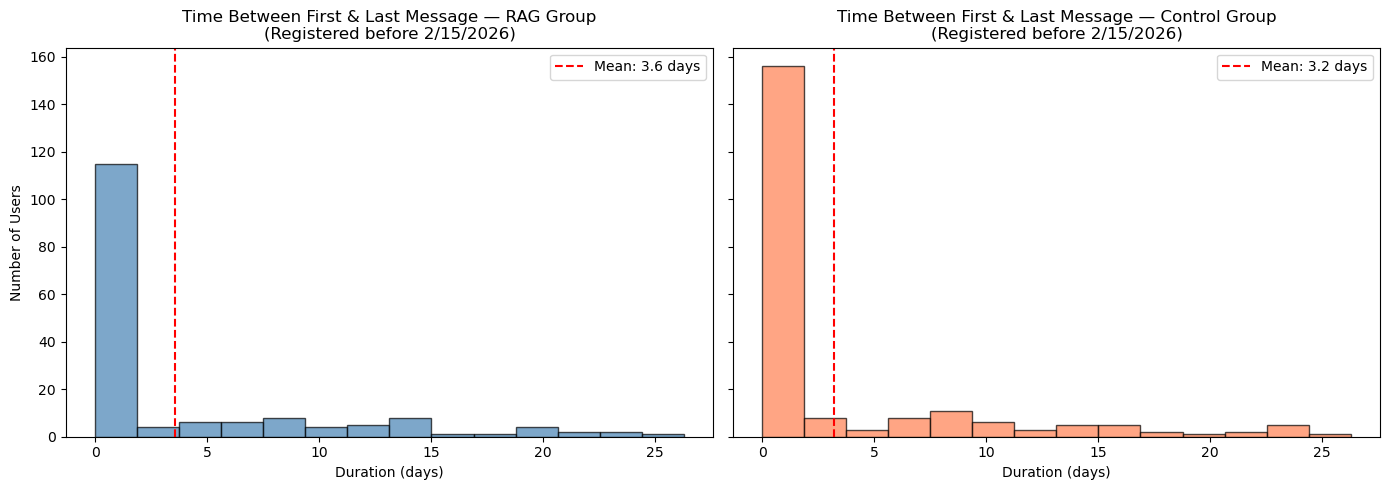

In [52]:
# --- Plotting Duration ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
max_duration = max(rag_user_times['duration_days'].max(), control_user_times['duration_days'].max())
if max_duration == 0: max_duration = 1 # handle case where all durations are zero
bins = np.linspace(0, max_duration, 15)

axes[0].hist(rag_user_times['duration_days'], bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Time Between First & Last Message — RAG Group\n(Registered before 2/15/2026)')
axes[0].set_xlabel('Duration (days)')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(rag_user_times['duration_days'].mean(), color='red', linestyle='--', label=f"Mean: {rag_user_times['duration_days'].mean():.1f} days")
axes[0].legend()

axes[1].hist(control_user_times['duration_days'], bins=bins, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Time Between First & Last Message — Control Group\n(Registered before 2/15/2026)')
axes[1].set_xlabel('Duration (days)')
axes[1].axvline(control_user_times['duration_days'].mean(), color='red', linestyle='--', label=f"Mean: {control_user_times['duration_days'].mean():.1f} days")
axes[1].legend()

plt.tight_layout()
plt.show()